<a href="https://colab.research.google.com/github/Chandrani45/AI-COURSE-RECOMMENDER-PROJECT-WORK-/blob/main/Copy_of_Chandrani_Sengupta_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LOADING THE LIBRARIES

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
!pip install groq

MODULE 0
Loading Groq

In [9]:
import os
from groq import Groq

In [10]:
import os
from getpass import getpass

os.environ["GROQ_API_KEY"] = getpass("Enter your Groq API key: ")

Enter your Groq API key: ··········


In [11]:
client = Groq()

response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[
        {"role": "system", "content": "You are a concise assistant."},
        {"role": "user", "content": "Explain why Groq's inference is fast in 3 sentences."},
    ],
)

print(response.choices[0].message.content)

Groq's inference is fast due to its custom-designed tensor processing units (TPUs) that are optimized for machine learning workloads. These TPUs are capable of performing complex matrix operations in a highly parallel and efficient manner, leading to significant speedups. Additionally, Groq's software stack is also optimized to work seamlessly with its hardware, allowing for end-to-end acceleration of inference pipelines and further boosting performance.


LOADING THE COURSE DATASET

In [12]:
course=pd.read_csv('/content/coursera_course_dataset_v3.csv')

PRINTING THE FIRST 5 ROWS

In [13]:
course.head()

,Unnamed: 0,Title,Organization,Skills,Ratings,course_url,course_students_enrolled,course_description,Review Count,Difficulty,Type,Duration
0,0,Google Cybersecurity,Google,"Network Security, Python Programming, Linux, ...",4.8,https://www.coursera.org/professional-certific...,"700,909",Google Cloud Fundamentals: Core Infrastructure...,20K,Beginner,Professional Certificate,3 - 6 Months
1,1,Google Data Analytics,Google,"Data Analysis, R Programming, SQL, Business C...",4.8,https://www.coursera.org/professional-certific...,"229,865",Prepare for a new career in the high-growth fi...,137K,Beginner,Professional Certificate,3 - 6 Months
2,3,Google Project Management:,Google,"Project Management, Strategy and Operations, ...",4.8,https://www.coursera.org/professional-certific...,"29,702",Prepare-se para uma nova carreira no campo de ...,100K,Beginner,Professional Certificate,3 - 6 Months
3,4,IBM Data Science,IBM,"Python Programming, Data Science, Machine Lea...",4.6,https://www.coursera.org/professional-certific...,"239,622",Prepare for a career in the high-growth field ...,120K,Beginner,Professional Certificate,3 - 6 Months
4,5,Google Digital Marketing & E-commerce,Google,"Digital Marketing, Marketing, Marketing Manag...",4.8,https://www.coursera.org/professional-certific...,"384,238",This course is the eighth course in the Google...,23K,Beginner,Professional Certificate,3 - 6 Months


We drop the unnamed column as it is of no use

In [14]:
course.rename(columns={'Unnamed: 0':'Course_id'},inplace=True)

In [15]:
course.head()

,Course_id,Title,Organization,Skills,Ratings,course_url,course_students_enrolled,course_description,Review Count,Difficulty,Type,Duration
0,0,Google Cybersecurity,Google,"Network Security, Python Programming, Linux, ...",4.8,https://www.coursera.org/professional-certific...,"700,909",Google Cloud Fundamentals: Core Infrastructure...,20K,Beginner,Professional Certificate,3 - 6 Months
1,1,Google Data Analytics,Google,"Data Analysis, R Programming, SQL, Business C...",4.8,https://www.coursera.org/professional-certific...,"229,865",Prepare for a new career in the high-growth fi...,137K,Beginner,Professional Certificate,3 - 6 Months
2,3,Google Project Management:,Google,"Project Management, Strategy and Operations, ...",4.8,https://www.coursera.org/professional-certific...,"29,702",Prepare-se para uma nova carreira no campo de ...,100K,Beginner,Professional Certificate,3 - 6 Months
3,4,IBM Data Science,IBM,"Python Programming, Data Science, Machine Lea...",4.6,https://www.coursera.org/professional-certific...,"239,622",Prepare for a career in the high-growth field ...,120K,Beginner,Professional Certificate,3 - 6 Months
4,5,Google Digital Marketing & E-commerce,Google,"Digital Marketing, Marketing, Marketing Manag...",4.8,https://www.coursera.org/professional-certific...,"384,238",This course is the eighth course in the Google...,23K,Beginner,Professional Certificate,3 - 6 Months


In [16]:
course.columns

Index(['Course_id', 'Title', 'Organization', 'Skills', 'Ratings', 'course_url',
       'course_students_enrolled', 'course_description', 'Review Count',
       'Difficulty', 'Type', 'Duration'],
      dtype='object')

In [17]:
course.columns=course.columns.str.lower()


In [18]:
course.head()

,course_id,title,organization,skills,ratings,course_url,course_students_enrolled,course_description,review count,difficulty,type,duration
0,0,Google Cybersecurity,Google,"Network Security, Python Programming, Linux, ...",4.8,https://www.coursera.org/professional-certific...,"700,909",Google Cloud Fundamentals: Core Infrastructure...,20K,Beginner,Professional Certificate,3 - 6 Months
1,1,Google Data Analytics,Google,"Data Analysis, R Programming, SQL, Business C...",4.8,https://www.coursera.org/professional-certific...,"229,865",Prepare for a new career in the high-growth fi...,137K,Beginner,Professional Certificate,3 - 6 Months
2,3,Google Project Management:,Google,"Project Management, Strategy and Operations, ...",4.8,https://www.coursera.org/professional-certific...,"29,702",Prepare-se para uma nova carreira no campo de ...,100K,Beginner,Professional Certificate,3 - 6 Months
3,4,IBM Data Science,IBM,"Python Programming, Data Science, Machine Lea...",4.6,https://www.coursera.org/professional-certific...,"239,622",Prepare for a career in the high-growth field ...,120K,Beginner,Professional Certificate,3 - 6 Months
4,5,Google Digital Marketing & E-commerce,Google,"Digital Marketing, Marketing, Marketing Manag...",4.8,https://www.coursera.org/professional-certific...,"384,238",This course is the eighth course in the Google...,23K,Beginner,Professional Certificate,3 - 6 Months


In [19]:
#print rows and columns
course.shape

(623, 12)

The data has 623 rows and 11 columns

In [20]:
role_skills={'Data Scientist': ['python', 'statistics', 'machine learning', 'sql',
                           'data visualization', 'deep learning'], 'Data Analyst': ['excel', 'sql', 'statistics', 'data visualization', 'python'], 'ML Engineer':['python', 'machine learning', 'deep learning', 'sql', 'cloud'],'Data Engineer': ['python','sql', 'data wrangling', 'cloud', 'big data', 'apis'], 'Business Analyst': ['excel', 'sql', 'statistics', 'data visualization',
                           'communication'],'BI Developer': ['sql', 'data visualization', 'excel', 'statistics', 'power bi'],'AI Researcher':['python', 'deep learning', 'machine learning',
                           'mathematics', 'nlp'], 'Backend Developer': ['python', 'sql', 'apis', 'cloud', 'git'],'MLOps Engineer':['python', 'machine learning', 'cloud', 'docker', 'mlops'], 'NLP Engineer':['python', 'machine learning', 'deep learning', 'nlp',
                           'statistics']



}

In [21]:
role_skills['Data Scientist']

['python',
 'statistics',
 'machine learning',
 'sql',
 'data visualization',
 'deep learning']

In [22]:
course.isnull().sum()

,0
course_id,0
title,0
organization,0
skills,0
ratings,0
course_url,220
course_students_enrolled,236
course_description,221
review count,0
difficulty,0


In [23]:
course.duplicated().sum()

np.int64(0)

No duplicates as such

In [24]:
course.drop(columns=['organization','ratings','course_url' ,	'course_students_enrolled' ,'course_description', 'review count','difficulty','type','duration'],axis=1,inplace=True)

In [25]:
course.isnull().sum()

,0
course_id,0
title,0
skills,0


In [26]:
course.head()

,course_id,title,skills
0,0,Google Cybersecurity,"Network Security, Python Programming, Linux, ..."
1,1,Google Data Analytics,"Data Analysis, R Programming, SQL, Business C..."
2,3,Google Project Management:,"Project Management, Strategy and Operations, ..."
3,4,IBM Data Science,"Python Programming, Data Science, Machine Lea..."
4,5,Google Digital Marketing & E-commerce,"Digital Marketing, Marketing, Marketing Manag..."


In [27]:
course.shape

(623, 3)

In [28]:
#cleaning the skills dataset
import re
def clean(text):
  return re.sub(r'[^a-z0-9]','',text.str.lower())
  return re.sub(r'\s+',"",text).strip()

In [29]:
import re

def clean(s):
    s = re.sub(r"[^a-z0-9 ]", " ", str(s).lower())
    return re.sub(r"\s+", " ", s).strip()

# build the search text from Title + Skills  (note the " " between them)
course['text'] = (course['title'] + " " + course['skills']).apply(clean)

# keep a clean LIST of skills — M6 needs this
course['skills'] = course['skills'].fillna("").apply(
    lambda s: [x.strip().lower() for x in str(s).split(",") if x.strip()])

course[['course_id', 'title', 'skills', 'text']].head(3)

,course_id,title,skills,text
0,0,Google Cybersecurity,"[network security, python programming, linux, ...",google cybersecurity network security python p...
1,1,Google Data Analytics,"[data analysis, r programming, sql, business c...",google data analytics data analysis r programm...
2,3,Google Project Management:,"[project management, strategy and operations, ...",google project management project management s...


In [30]:
course.head()

,course_id,title,skills,text
0,0,Google Cybersecurity,"[network security, python programming, linux, ...",google cybersecurity network security python p...
1,1,Google Data Analytics,"[data analysis, r programming, sql, business c...",google data analytics data analysis r programm...
2,3,Google Project Management:,"[project management, strategy and operations, ...",google project management project management s...
3,4,IBM Data Science,"[python programming, data science, machine lea...",ibm data science python programming data scien...
4,5,Google Digital Marketing & E-commerce,"[digital marketing, marketing, marketing manag...",google digital marketing e commerce digital ma...


In [31]:
course['text'].iloc[0]

'google cybersecurity network security python programming linux cloud computing algorithms audit computer programming computer security incident management cryptography databases leadership and management network architecture risk management sql'

In [32]:
target_role = input('Enter a role: ').strip()
assert target_role in role_skills, f"'{target_role}' is not in the role list. Pick one of: {list(role_skills)}"

Enter a role: Data Scientist


In [33]:
target_role

'Data Scientist'

In [34]:
current_skills = [s.strip().lower() for s in input('Enter your current skills (comma-separated): ').split(",") if s.strip()]
have = set(current_skills)


Enter your current skills (comma-separated): python


In [35]:
have

{'python'}

In [36]:
skill_gap = [s for s in role_skills[target_role] if s.lower() not in have]
query_text = " ".join(skill_gap)
print("skill_gap:", skill_gap)

skill_gap: ['statistics', 'machine learning', 'sql', 'data visualization', 'deep learning']


In [37]:
query_text

'statistics machine learning sql data visualization deep learning'

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [39]:
tfidf=TfidfVectorizer(stop_words='english')

In [40]:
course_vector=tfidf.fit_transform(course['text']).toarray()

In [41]:
from sklearn.metrics.pairwise import cosine_similarity

In [42]:
def recommend(query_text):
  query_vector=tfidf.transform([query_text])
  similarity=cosine_similarity(course_vector,query_vector).flatten()
  course_list=course.copy()
  course_list['score']=similarity
  course_list=course_list.sort_values(by='score',ascending=False)
  return course_list.head(10)

In [43]:
result_tfdif=recommend(query_text)

In [44]:
result_tfdif

,course_id,title,skills,text,score
194,200,Machine Learning on Google Cloud,"[machine learning, applied machine learning, g...",machine learning on google cloud machine learn...,0.642587
7,9,Machine Learning,"[machine learning, machine learning algorithms...",machine learning machine learning machine lear...,0.635728
93,97,IBM Machine Learning,"[machine learning, machine learning algorithms...",ibm machine learning machine learning machine ...,0.629923
519,525,Applying Machine Learning to your Data with Go...,"[applied machine learning, big data, cloud com...",applying machine learning to your data with go...,0.618981
288,294,Deep Neural Networks with PyTorch,"[human learning, machine learning, deep learni...",deep neural networks with pytorch human learni...,0.614771
408,414,Introduction to Artificial Intelligence (AI),"[algorithms, applied machine learning, artific...",introduction to artificial intelligence ai alg...,0.606391
149,155,"Unsupervised Learning, Recommenders, Reinforce...","[algorithms, machine learning, machine learnin...",unsupervised learning recommenders reinforceme...,0.598838
87,91,Advanced Learning Algorithms,"[applied machine learning, machine learning, m...",advanced learning algorithms applied machine l...,0.595222
39,43,IBM AI Engineering,"[machine learning, deep learning, artificial n...",ibm ai engineering machine learning deep learn...,0.591767
100,105,IBM Introduction to Machine Learning,"[machine learning, machine learning algorithms...",ibm introduction to machine learning machine l...,0.590942


In [45]:
from sentence_transformers import SentenceTransformer,util

In [46]:
model=SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [47]:
course_embedding=model.encode(course['text'].tolist(),convert_to_tensor=False)

In [48]:
#course_embedding

In [49]:
def recommend2(query_text):
  query_vector2=model.encode([query_text],convert_to_tensor=False)
  similarity=cosine_similarity(course_embedding,query_vector2).flatten()
  course_list=course.copy()
  course_list['score_embedding']=similarity
  course_list=course_list.sort_values(by='score_embedding',ascending=False)
  return course_list.head(10)

In [50]:
result_embedding=recommend2(query_text)

In [51]:
result_embedding

,course_id,title,skills,text,score_embedding
366,372,Data Analytics for Lean Six Sigma,"[probability & statistics, data visualization,...",data analytics for lean six sigma probability ...,0.525871
297,303,From Data to Insights with Google Cloud,"[google cloud platform, cloud computing, sql, ...",from data to insights with google cloud google...,0.512695
214,220,Share Data Through the Art of Visualization,"[business communication, data analysis, data v...",share data through the art of visualization bu...,0.504352
345,351,1. 基礎知識：データはあらゆるところにある,"[data analysis, business analysis, data visual...",1 data analysis business analysis data visuali...,0.498769
420,426,Understanding and Visualizing Data with Python,"[basic descriptive statistics, data analysis, ...",understanding and visualizing data with python...,0.491735
48,52,"Foundations: Data, Data, Everywhere","[data analysis, sql, data visualization, busin...",foundations data data everywhere data analysis...,0.491105
412,418,"Sequences, Time Series and Prediction","[machine learning, forecasting, tensorflow, ap...",sequences time series and prediction machine l...,0.480311
23,27,Data Analysis and Visualization Foundations,"[microsoft excel, data visualization, spreadsh...",data analysis and visualization foundations mi...,0.475694
379,385,"Decisions, Decisions: Dashboards and Reports","[business intelligence, data model, data visua...",decisions decisions dashboards and reports bus...,0.475412
143,149,Introduction to Data Analytics,"[data analysis, databases, python programming,...",introduction to data analytics data analysis d...,0.471046


In [52]:
def is_relevant(course_skills,skill_gap):
  course_skills=set(course_skills)
  skill_gap=set(skill_gap)
  return len(course_skills & skill_gap)>0

In [53]:
def precision_at_k(recommendations,skill_gap,k):
  relevant=0
  for _,row in recommendations.head(k).iterrows():
    if is_relevant(row['skills'],skill_gap):
      relevant+=1

  return relevant/k

In [54]:
skill_gap

['statistics',
 'machine learning',
 'sql',
 'data visualization',
 'deep learning']

In [55]:
precisiontfdif=precision_at_k(result_tfdif,skill_gap,10)
print(precisiontfdif)

1.0


In [56]:
precision_embedding=precision_at_k(result_embedding,skill_gap,10)
print(precision_embedding)

1.0


In [57]:
def evaluate_role(target_role, current_skills, k=10):
    have = {s.strip().lower() for s in current_skills}
    skill_gap = [s for s in role_skills[target_role] if s.lower() not in have]
    query_text = " ".join(skill_gap)

    tfidf_recs = recommend(query_text)
    emb_recs   = recommend2(query_text)

    p_tfidf = precision_at_k(tfidf_recs, skill_gap, k)
    p_emb   = precision_at_k(emb_recs,  skill_gap, k)

    print(f"\n=== {target_role} | have={current_skills} ===")
    print("skill gap:", skill_gap)
    print("TF-IDF top-5:", tfidf_recs['title'].head(5).tolist())
    print("Embed  top-5:", emb_recs['title'].head(5).tolist())
    print(f"Precision@{k} -> TF-IDF={p_tfidf:.2f}  Embedding={p_emb:.2f}")
    return {"role": target_role, "p_tfidf": p_tfidf, "p_emb": p_emb}

scenarios = [
    ("Data Scientist", ["python"]),
    ("Data Analyst",   ["excel"]),
    ("NLP Engineer",   ["python", "machine learning"]),
]

rows = [evaluate_role(r, s) for r, s in scenarios]
import pandas as pd
pd.DataFrame(rows)



=== Data Scientist | have=['python'] ===
skill gap: ['statistics', 'machine learning', 'sql', 'data visualization', 'deep learning']
TF-IDF top-5: ['Machine Learning on Google Cloud', 'Machine Learning', 'IBM Machine Learning', 'Applying Machine Learning to your Data with Google Cloud', 'Deep Neural Networks with PyTorch']
Embed  top-5: ['Data Analytics for Lean Six Sigma', 'From Data to Insights with Google Cloud', 'Share Data Through the Art of Visualization', '1. 基礎知識：データはあらゆるところにある', 'Understanding and Visualizing Data with Python']
Precision@10 -> TF-IDF=1.00  Embedding=1.00

=== Data Analyst | have=['excel'] ===
skill gap: ['sql', 'statistics', 'data visualization', 'python']
TF-IDF top-5: ['Data Visualization with Python', 'SQL für Data Science', 'Data Analysis and Visualization Foundations', 'Statistics for Data Science with Python', 'Understanding and Visualizing Data with Python']
Embed  top-5: ['Understanding and Visualizing Data with Python', 'Data Visualization with Pytho

,role,p_tfidf,p_emb
0,Data Scientist,1.0,1.0
1,Data Analyst,1.0,1.0
2,NLP Engineer,0.9,0.4


In [58]:
rows

[{'role': 'Data Scientist', 'p_tfidf': 1.0, 'p_emb': 1.0},
 {'role': 'Data Analyst', 'p_tfidf': 1.0, 'p_emb': 1.0},
 {'role': 'NLP Engineer', 'p_tfidf': 0.9, 'p_emb': 0.4}]

In [59]:
prompt=f"""The user wants to become a {target_role}

current skills:
{current_skills}

missing skills:
{
    skill_gap
}

recommended courses:

{
    result_tfdif['title'].head(10).tolist()
}

Create a learning roadmap in order
"""

In [60]:
response=client.chat.completions.create(model="llama-3.3-70b-versatile" , messages=[{'role':'user','content':prompt}])
print(response.choices[0].message.content)

To become a Data Scientist, you'll need to acquire the missing skills in a logical order. Here's a suggested learning roadmap:

**Phase 1: Fundamentals (Statistics, SQL)**

1. Start with **Statistics**:
	* Take online courses or tutorials that cover statistical concepts, such as probability, inference, and regression.
	* Familiarize yourself with statistical libraries in Python, like Pandas and NumPy.
2. Learn **SQL**:
	* Understand the basics of database management and querying.
	* Practice writing SQL queries using online platforms or databases.

**Phase 2: Machine Learning and Data Visualization**

1. Learn the basics of **Machine Learning**:
	* Enroll in a course like **Machine Learning** or **Introduction to Machine Learning**.
	* Focus on understanding supervised and unsupervised learning concepts.
2. Learn **Data Visualization**:
	* Study data visualization libraries in Python, such as Matplotlib, Seaborn, or Plotly.
	* Practice creating informative and engaging visualizations.


In [61]:
prompt2=f"""The user wants to become a {target_role}

current skills:
{current_skills}

missing skills:
{
    skill_gap
}

recommended courses:

{
    result_embedding['title'].head(10).tolist()
}

Create a learning roadmap in order
"""

In [62]:
response2=client.chat.completions.create(model="llama-3.3-70b-versatile" , messages=[{'role':'user','content':prompt2}])
print(response2.choices[0].message.content)

To create a learning roadmap for becoming a Data Scientist, we need to prioritize the missing skills and recommend courses that cover those skills. Here's a suggested learning roadmap in order:

**Phase 1: Statistics and Data Analysis**

1. **Foundations: Data, Data, Everywhere** (intro to data concepts)
2. **Data Analysis and Visualization Foundations** ( covers basic data analysis)
3. **Understanding and Visualizing Data with Python** (utilizes existing Python skills)

These courses will introduce you to data concepts, statistics, and basic data analysis using Python.

**Phase 2: Data Visualization and SQL**

1. **Share Data Through the Art of Visualization** (develops data visualization skills)
2. **Data Analytics for Lean Six Sigma** (includes some data visualization and analysis)
3. **SQL course** (not explicitly listed, but you can take an introductory SQL course, e.g., "SQL for Data Science" or a similar course)

These courses will help you develop data visualization skills and 

   method  precision
   TF-IDF        1.0
Embedding        1.0
winner: Embedding


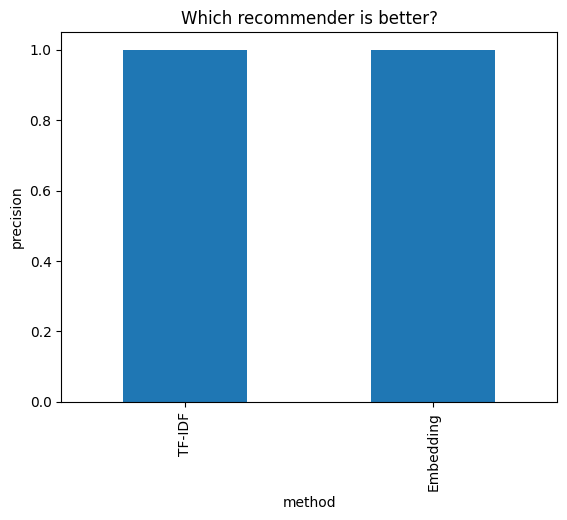

In [71]:
eval_table = pd.DataFrame({"method":["TF-IDF","Embedding"], "precision":[precisiontfdif, precision_embedding]})
winner = "Embedding" if precision_embedding>= precisiontfdif else "TF-IDF"
print(eval_table.to_string(index=False)); print("winner:", winner)
# A single user at k=10 can tie at 1.0 - evaluate several roles & k values for real discrimination.
eval_table.plot.bar(x="method", y="precision", legend=False)
plt.title("Which recommender is better?"); plt.ylabel("precision"); plt.ylim(0,1.05); plt.show()

In [73]:
def make_roadmap(current_skills, target_role, skill_gap, best_recs):
    # Uses Groq if GROQ_API_KEY is set; otherwise returns a simple offline list.
    course_list = "\n".join(f"- {t}" for t in best_recs["title"].head(8))
    api_key = os.environ.get("GROQ_API_KEY")
    if api_key:
        try:
            from groq import Groq
            prompt = (
                f"You are helping a learner plan their upskilling.\n\n"
                f"Current skills: {', '.join(current_skills) or 'none'}\n"
                f"Target role: {target_role}\n"
                f"Skills they still need (the gap): {', '.join(skill_gap)}\n\n"
                f"Recommended courses - use ONLY these, do not invent any:\n{course_list}\n\n"
                "Write a month-by-month learning roadmap that uses ONLY the courses above, "
                "orders foundational skills before advanced ones, one short sentence per course, "
                "realistic over ~6-8 months, ending with a line that this is a SUGGESTED order, "
                "not a verified prerequisite plan."
            )
            resp = Groq(api_key=api_key).chat.completions.create(
                model="openai/gpt-oss-120b",
                messages=[{"role": "user", "content": prompt}])
            return resp.choices[0].message.content, True
        except Exception as e:
            print("Groq call failed, using offline sample:", e)
    lines = [f"Suggested roadmap toward {target_role} (offline sample):", ""]
    lines += [f"- Month {i}: {t}" for i, t in enumerate(best_recs["title"].head(8), 1)]
    lines += ["", "This is a SUGGESTED order, not a verified prerequisite plan."]
    return "\n".join(lines), False

best_recs = result_embedding if winner == "Embedding" else result_tfdif
roadmap_text, used_llm = make_roadmap(current_skills, target_role, skill_gap, best_recs)
print(("LIVE (Groq)" if used_llm else "OFFLINE sample") + " roadmap:\n")
print(roadmap_text)

LIVE (Groq) roadmap:

**Month 1 – Foundations: Data, Data, Everywhere** – Learn what data is, how it’s collected, and the basic terminology used across analytics.  

**Month 2 – 1. 基礎知識：データはあらゆるところにある** – Gain a global view of data sources and the importance of data quality in real‑world settings.  

**Month 3 – Data Analysis and Visualization Foundations** – Build core statistical thinking and simple visual‑exploratory techniques.  

**Month 4 – Understanding and Visualizing Data with Python** – Apply Python libraries (pandas, matplotlib, seaborn) to clean, explore, and plot data.  

**Month 5 – Share Data Through the Art of Visualization** – Advance to storytelling with charts, dashboards, and design principles for effective communication.  

**Month 6 – Data Analytics for Lean Six Sigma** – Study statistical methods (hypothesis testing, regression) and see how they support process‑improvement and SQL‑based data extraction.  

**Month 7 – Sequences, Time Series and Prediction** – Int

In [76]:
import gradio as gr

def _recommend(scores, k):
    top = scores.argsort()[::-1][:k]
    recs = course.loc[top, ["course_id", "title"]].copy()
    recs["score"] = scores[top].astype(float).round(3)
    recs["rank"] = range(1, len(recs) + 1)
    return recs[["rank", "course_id", "title", "score"]].reset_index(drop=True)

def run(target_role, current_skills, k):
    have = {s.lower() for s in (current_skills or [])}
    gap = [s for s in role_skills[target_role] if s.lower() not in have]              # M3
    if not gap:
        note = f"You already have every skill {target_role} needs. Try another role."
        empty = pd.DataFrame(columns=["rank","course_id","title","score"])
        return note, empty, empty, "", ""
    q = " ".join(gap)
    tf = _recommend(cosine_similarity(tfidf.transform([q]),course_vector).flatten(), k)        # M4
    em = _recommend(cosine_similarity(model.encode([q]), course_embedding).flatten(), k)     # M5
    p_tf = precision_at_k(tf, course, gap, k)
    p_em = precision_at_k(em, course, gap, k)
    winner = "Embedding" if p_em >= p_tf else "TF-IDF"
    best = em if winner == "Embedding" else tf
    gap_md = f"**Skill gap:** {', '.join(gap)}"
    if abs(p_tf - p_em) < 1e-9:
        win_md = (f"**Tie** - both score precision = {p_tf:.2f}. The methods differ in "
                  "*which* courses they surface (keywords vs meaning).")
    else:
        win_md = f"**Winner: {winner}** - precision: TF-IDF {p_tf:.2f} vs Embedding {p_em:.2f}"
    roadmap, _ = make_roadmap(list(have), target_role, gap, best)                       # M7
    roadmap = "  \n".join(line for line in roadmap.splitlines() if line.strip())
    return gap_md, tf, em, win_md, roadmap

# Force light mode so everyone sees the same UI regardless of their browser's dark setting.
_css = """
:root, html.dark, .dark {
  color-scheme: light !important;
  --bg-dark: #f8fafc !important; --col-dark: #1e293b !important;
  --body-background-fill: #f8fafc !important; --body-text-color: #1e293b !important;
  --background-fill-primary: #ffffff !important; --background-fill-secondary: #f1f5f9 !important;
  --block-background-fill: #eef2fb !important; --input-background-fill: #ffffff !important;
  --border-color-primary: #dbe3f2 !important; --input-border-color: #cdd7ea !important;
  --table-even-background-fill: #ffffff !important; --table-odd-background-fill: #f4f7fd !important;
  --neutral-900: #eef2fb !important; --neutral-950: #ffffff !important;
}
html, body, .gradio-container { background: #ffffff !important; color: #1e293b !important; }
.block { box-shadow: 0 1px 2px rgba(15,23,42,.05) !important; }
.token { background: #dbe4ff !important; color: #312e81 !important;
         border: 1px solid #c3cffb !important; border-radius: 8px !important; }
.token .token-remove, .token-remove { color: #4f46e5 !important; background: transparent !important; }
"""
with gr.Blocks(title="Course Recommender", css=_css) as demo:
    gr.Markdown("# 🎓 Course Recommender & Career Roadmap\nPick a role and the skills you already have.")
    with gr.Row():
        role_in = gr.Dropdown(list(role_skills), value="Data Scientist", label="Target role")
        skills_in = gr.Dropdown(sorted({s for v in role_skills.values() for s in v}),
                                value=["python"], multiselect=True, label="Skills you already have")
        k_in = gr.Slider(5, 15, value=10, step=1, label="Top-k")
    go = gr.Button("Get recommendations & roadmap", variant="primary")
    gap_out = gr.Markdown()
    with gr.Row():
        tfidf_out = gr.Dataframe(label="TF-IDF (baseline)", interactive=False)
        embed_out = gr.Dataframe(label="Embedding (semantic)", interactive=False)
    winner_out = gr.Markdown()
    roadmap_out = gr.Markdown()
    go.click(run, [role_in, skills_in, k_in],
             [gap_out, tfidf_out, embed_out, winner_out, roadmap_out])

# share=True is what gives you the public link in Colab.
demo.launch(share=True)

/tmp/ipykernel_943/529299357.py:52: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: css. Please pass these parameters to launch() instead.
  with gr.Blocks(title="Course Recommender", css=_css) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c10412a4d65282dace.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
